<a href="https://colab.research.google.com/github/yuaquintero/CienciaModelado/blob/main/bicycle_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#para conectar el drive e importar el modelo
from google.colab import drivedrive.mount('/content/drive')


In [1]:
cd /content/drive/MyDrive/Colab Notebooks/CienciaModelado/BuckiNet


/content/drive/MyDrive/Colab Notebooks/CienciaModelado/BuckiNet


# Problema fisico:
Definir la trayectoria de la bicicleta


\begin{equation}
\dot{X}=Vcos(ψ+β)
\end{equation}

\begin{equation}
\dot{Y}=Vsin(ψ+β)
\end{equation}

\begin{equation}
\dot{ψ}= \frac{V}{l_r}sin(β)
\end{equation}

Donde β es el ángulo de deslizamiento del CG, calculado a partir de la geometría del vehículo y el ángulo de dirección δ:

\begin{equation} β = \arctan(\frac {l_r}{l_f+l_r} \tan(δ)) \end{equation}

carga de modelo de BuckiNet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Importamos las clases locales en src/model.py
# NOTA: correr este notebook desde la carpeta 'notebooks'
# y que exista el archivo '../src/model.py'
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.model import FullBuckiNet, buckinet_loss, BuckiNetLayer

# Configuración para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

## Paso 1. Generación de Datos Sintéticos

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import torch

def bicicleta_ode(t, y, V, delta, lf, lr):
    # y = [X, Y, psi]
    psi = y[2]
    L = lf + lr
    beta = np.arctan(np.tan(delta) * lr / L)

    # Ecuaciones acopladas de la trayectoria
    dx_dt = V * np.cos(psi + beta)
    dy_dt = V * np.sin(psi + beta)
    dpsi_dt = (V / L) * np.tan(delta) * np.cos(beta)

    return [dx_dt, dy_dt, dpsi_dt]

def generar_datos_sinteticos_ode(n_samples=10000):
    inputs = []
    targets = []

    for _ in range(n_samples):
        # Parámetros aleatorios (siempre positivos para BuckiNet)
        lf = np.random.uniform(1.0, 1.2)
        lr = np.random.uniform(1.2, 1.8)
        V = np.random.uniform(3.0, 15.0)
        delta = np.random.uniform(0.05, 0.4)
        t_final = np.random.uniform(0.1, 4.0)

        # Resolver el sistema acoplado
        sol = solve_ivp(
            bicicleta_ode,
            [0, t_final],
            [0.0, 0.0, 0.0], # Condiciones iniciales: X=0, Y=0, psi=0
            args=(V, delta, lf, lr),
            t_eval=[t_final]
        )

        if sol.status == 0:
            inputs.append([lf, lr, delta, V, t_final])
            # Guardamos X, Y, psi al tiempo t_final
            targets.append([sol.y[0,0], sol.y[1,0], sol.y[2,0]])

    return torch.tensor(inputs, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)

# Crear dataset
X_train, Y_train = generar_datos_sinteticos_ode(10000)

In [4]:
print(f"\nTensores creados:")
print(f"   X_train (entradas): shape {X_train.shape}")
print(f"   Y_train (salidas):  shape {Y_train.shape}")


Tensores creados:
   X_train (entradas): shape torch.Size([10000, 5])
   Y_train (salidas):  shape torch.Size([10000, 3])


## Paso 2. Configuración de la Red y la Física

Matriz Dimencional, solo tenemos Longitud (L) y Tiempo (T).


| Variable | Unidades | Longitud (L) | Tiempo (T) |
| :--- | :--- | :---: | :---: |
| l_f| $m$ | 1 | 0 |
|l_r | $m$ | 1 | 0 |
| δ| $º$ | 0 | 0 |
| V | $m/s$ | 1 | -1 |
| t | $s$ | 0 | 1 |



In [5]:
# Dimensiones: Longitud [L], Tiempo [T]
# Variables: [l_f, l_r, δ, V, t]


print("\nMatriz dimensional D_p (2 filas x 5 columnas):")
print("   Filas: [Longitud (L), Tiempo (T)]")
print("   Columnas: [l_f, l_r, δ, V,  t]")

print("Matriz Dimensional D_p (Bicicleta):")

D_p_numpy = np.array([
    #  l_f  l_r   δ    V    t
    [   1,   1,   0,   1,   0 ],   # Longitud (L)
    [   0,   0,   0,  -1,   1 ]    # Tiempo (T)
], dtype=np.float32)

D_p = torch.tensor(D_p_numpy, dtype=torch.float32)

print("\n" + str(D_p.numpy()))
# Instanciamos el modelo
# Usamos un poco más de neuronas ocultas porque ahora hay 3 salidas acopladas
# Arquitectura:
# - 6 entradas: [l_f, l_r, δ, V, t] -> n
# - 2 dimensiones fundamentales -> k
# - 4 grupos Pi (teorema Pi: n-k = 6-2 = 4)
# - 3 salidas: [X, Y, ψ]
# - 128 neuronas en capa oculta

modelo = FullBuckiNet(
    num_inputs=5,        # l_f, l_r, δ, V, t
    num_pi_groups=3,     # 3 grupos adimensionales
    num_outputs=3,       # X, Y, ψ
    hidden_neurons=128
)

# Optimizador Adam con learning rate moderado
optimizador = optim.Adam(modelo.parameters(), lr=0.001)


Matriz dimensional D_p (2 filas x 5 columnas):
   Filas: [Longitud (L), Tiempo (T)]
   Columnas: [l_f, l_r, δ, V,  t]
Matriz Dimensional D_p (Bicicleta):

[[ 1.  1.  0.  1.  0.]
 [ 0.  0.  0. -1.  1.]]


## Paso 3. Bucle de Entrenamiento

Usamos Buckinet

In [6]:
import torch.nn as nn

# 1. Parámetros de entrenamiento
num_epochs = 5000
lambda_fisica = 10.0  # Empezamos con una penalización fuerte
historial_total = []
historial_mse = []
historial_fisica = []
#l1_reg=1e-3, l2_reg=1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)
D_p = D_p.to(device)
X_train = X_train.to(device)
Y_train = Y_train.to(device)

print("Iniciando entrenamiento de BuckiNet para Trayectoria Acoplada...")

for epoch in range(num_epochs):
    modelo.train()
    optimizador.zero_grad()

    # Forward: Predicción y obtención de Phi_p (los exponentes de Buckingham)
    predicciones, Phi_p = modelo(X_train)

    # Cálculo de las pérdidas usando tu función buckinet_loss
    # Nota: buckinet_loss ya suma mse_loss + lambda * null_space_penalty
    total_loss = buckinet_loss(predicciones, Y_train, Phi_p, D_p, lambda_null=lambda_fisica)

    # Para monitoreo: calculamos los componentes por separado
    with torch.no_grad():
        mse_comp = nn.MSELoss()(predicciones, Y_train)
        # La penalización es ||D_p @ Phi_p||^2
        fisica_comp = torch.sum(torch.square(torch.matmul(D_p, Phi_p)))

    # Backward y optimización
    total_loss.backward()
    optimizador.step()

    # Guardar progreso
    historial_total.append(total_loss.item())
    historial_mse.append(mse_comp.item())
    historial_fisica.append(fisica_comp.item())

    # Imprimir progreso cada 200 épocas
    if epoch % 200 == 0:
        print(f"Época [{epoch}/{num_epochs}] | "
              f"MSE (Datos): {mse_comp.item():.6f} | "
              f"Física (Nulo): {fisica_comp.item():.6f} |"
              f"Pérdida total: {total_loss.item():.6f}")

print("\nEntrenamiento completado.")

Iniciando entrenamiento de BuckiNet para Trayectoria Acoplada...
Época [0/5000] | MSE (Datos): 85.893707 | Física (Nulo): 10.536080 |Pérdida total: 191.266769
Época [200/5000] | MSE (Datos): 19.541927 | Física (Nulo): 6.266315 |Pérdida total: 82.215462
Época [400/5000] | MSE (Datos): 9.883895 | Física (Nulo): 3.749526 |Pérdida total: 47.387997
Época [600/5000] | MSE (Datos): 3.118099 | Física (Nulo): 2.232659 |Pérdida total: 25.453064
Época [800/5000] | MSE (Datos): 1.328468 | Física (Nulo): 1.265418 |Pérdida total: 13.990923
Época [1000/5000] | MSE (Datos): 0.768019 | Física (Nulo): 0.677170 |Pérdida total: 7.547886
Época [1200/5000] | MSE (Datos): 0.493313 | Física (Nulo): 0.336392 |Pérdida total: 3.865333
Época [1400/5000] | MSE (Datos): 0.350317 | Física (Nulo): 0.153128 |Pérdida total: 1.889647
Época [1600/5000] | MSE (Datos): 0.276125 | Física (Nulo): 0.063669 |Pérdida total: 0.920823
Época [1800/5000] | MSE (Datos): 0.230450 | Física (Nulo): 0.024646 |Pérdida total: 0.484881
Épo

## Paso 4. Gráfico la función de pérdida

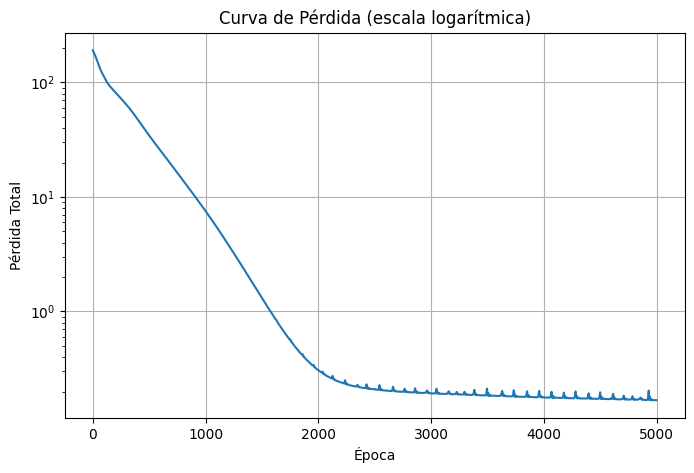

In [7]:
#============================================
# Visualización de resultados
# ============================================

# Evaluamos el modelo en todo el conjunto
with torch.no_grad():
    predicciones, Phi_final = modelo(X_train)

    # Desnormalizamos las predicciones
    #predicciones = predicciones_norm * Y_std + Y_mean

# Gráfica de pérdida
plt.figure(figsize=(8, 5))
plt.plot(historial_total)
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Pérdida Total')
plt.title('Curva de Pérdida (escala logarítmica)')
plt.grid(True)

## Paso 5. Interpretación de los exponentes

In [9]:
phi_final = modelo.pi_layer.Phi_p.detach().numpy()

import pandas as pd
# Creamos un DataFrame para que sea legible
# Filas: Nuestras variables de entrada
# Columnas: Los 3 grupos Pi que la red intentó formar
variables = ['l_f', 'l_r', 'delta', 'V', 't']
df_pi = pd.DataFrame(phi_final, index=variables, columns=['Pi_1', 'Pi_2', 'Pi_3'])

print("Matriz de Exponentes Aprendida (Phi_p):")
print(df_pi.round(4))

Matriz de Exponentes Aprendida (Phi_p):
         Pi_1    Pi_2    Pi_3
l_f   -0.2739  0.7505  0.3142
l_r   -0.4674 -0.2312 -0.2681
delta  1.1145 -0.8769 -0.4185
V      0.7250 -0.5507 -0.0018
t      0.7222 -0.5524 -0.0003
